In [1]:
from classes import *

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [3]:
corpus_removal_threshold     = 1
vectorizer_removal_threshold = 2
grouping_similarity          = .6
filepath = 'recipes'

In [4]:
corpus = Corpus(
    filepath          = f'corpora/{filepath}',
    spell_correct     = 'corpora/spelling_dictionary',
    lemmatize         = False,
    removal_threshold = corpus_removal_threshold)

vectorizer = corpus.create_vectorizer(removal_threshold = vectorizer_removal_threshold)

Data collected:
    - 4107 unique words found.
    - most common words: ['\n', '-', '.', '1', ',']
    - least common words: ['www', 'yet', 'zinfandel', 'zip', 'zipper']


Corpus loaded:
    - 5000 sentences.
    - longest sentence: 

<START> whole wheat yeast bread 
 
 ingredients : 
 - 1 cup ( 2 2 5 ml ) scalded milk 
 - 1 / 4 cup ( 6 0 ml ) lard 
 - 4 tsp ( 2 0 ml ) . salt 
 - 1 / 4 cup ( 6 0 ml ) honey 
 - 1 cup ( 2 2 5 ml ) water , 1 1 0 - 1 1 5 degrees 
 - 2 pkg . dry yeast 
 - 2 tbsp ( 3 0 ml ) . brown sugar 
 - 2 cups ( 4 7 5 ml ) whole wheat flour 
 - 3 cups ( 7 0 0 ml ) or more white flour 
 
 directions : 
 - mix scalded milk , lard , salt & honey and let cool to lukewarm - about 8 5 degrees ( 3 0 c . ) . 
 - mix water , yeast & brown sugar and let stand to dissolve for 2 - 3 minutes . 
 - add yeast mixture to milk mixture . 
 - add whole wheat flour and enough white flour to make dough . 
 - mix well . 
 - knead 5 - 1 0 minutes . 
 - put in bowl to rise until double in size

In [5]:
model = Pipeline(steps=[
    ('wv', FunctionTransformer(vectorizer.vectorize)),
    ('pca', PCA(n_components=2))
])

In [ ]:
num_words = 500
plot_size = 50
# in VScode, you can click on the top right of a plot to view it in the Plot Viewer.

/Users/josh/Documents/GitHub/CRV-Playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


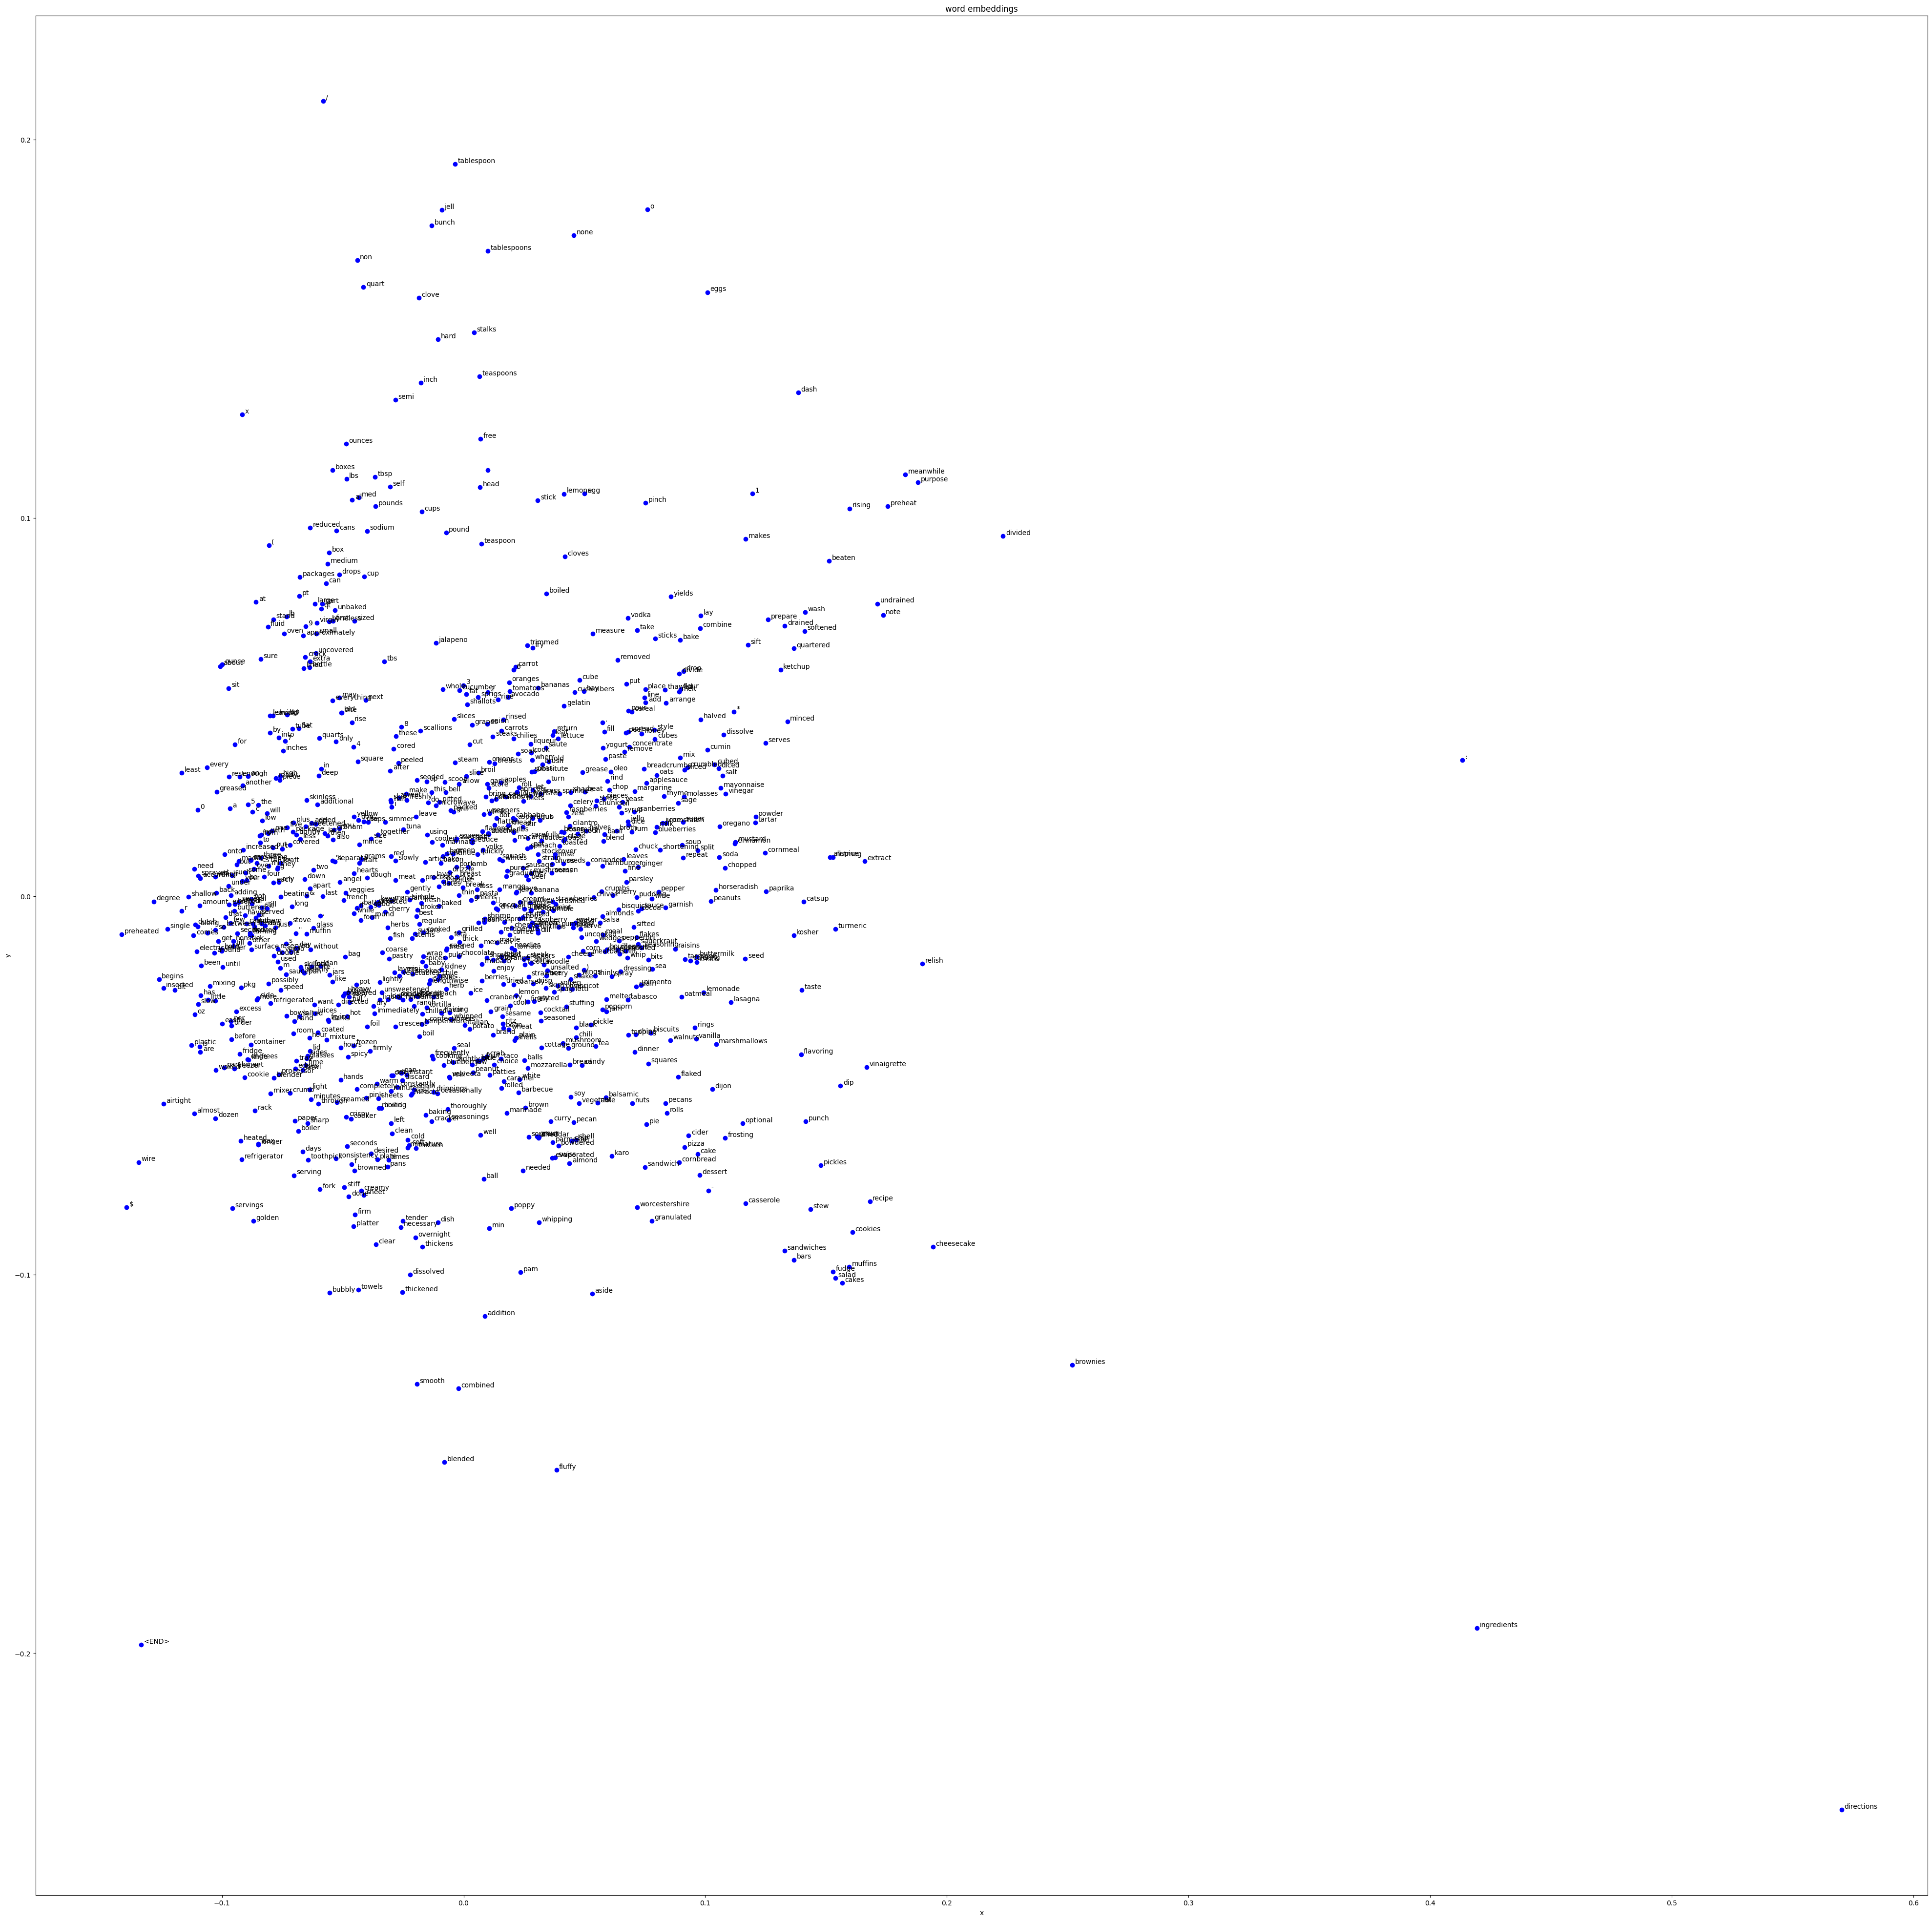

In [9]:
terms = vectorizer.vocab[:num_words]

x, y = model.fit_transform(terms).T

fig, ax = plt.subplots(figsize=(plot_size, plot_size))
ax.scatter(x, y, c='b')

for i, term in enumerate(terms):
    ax.annotate(
        term,
        (x[i], y[i]),
        xytext=(4, 2),
        textcoords='offset points'
    )

plt.title('word embeddings')
plt.xlabel('x')
plt.ylabel('y')
plt.show()